In [1]:
import pandas as pd
import lightgbm as lgb
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
import requests
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
import stumpy
import numpy as np
from scipy.spatial.distance import cdist

import random

import matplotlib.cm as cm

from distancematrix import AnytimeCalculator
from distancematrix.consumer import MatrixProfileLR
from distancematrix.generator import ZNormEuclidean
from distancematrix.generator import Euclidean
from distancematrix.insights import highest_value_idxs, lowest_value_idxs


from scipy.sparse import lil_matrix, csr_matrix
import matplotlib.ticker as mticker

In [2]:
VIRTUOSO_URL = "http://localhost:8890/sparql"
GRAPH_URI    = "http://example.com/Gent-Terneuzen"
USERNAME     = "dba"
PASSWORD     = "dba"
AUTH         = (USERNAME, PASSWORD)

In [3]:
params  = {'graph': GRAPH_URI}
headers = {'Accept': 'text/turtle'}

# Identifying unique sensors


In [4]:
sensor_set = set()

sensor_query = f"""
    PREFIX sosa: <http://www.w3.org/ns/sosa/>
    SELECT DISTINCT ?sensor
    WHERE {{
        GRAPH <{GRAPH_URI}> {{
            ?obs a sosa:Observation ;
                 sosa:madeBySensor ?sensor .
        }}
    }}
    """
res = requests.get(VIRTUOSO_URL, params={'query': sensor_query, 'format': 'application/sparql-results+json'})
if res.status_code != 200:
    print(f"Error: {res.status_code}")
    print("Response:", res.text)
else:
    print("Unique sensors identified successfully!")

data     = res.json()
bindings = data['results']['bindings']
for row in bindings:
    sensor_set.add(row['sensor']['value'])

print(f"Added {len(sensor_set)} unique sensors to the set.")
print("Sensors:", sensor_set)

Unique sensors identified successfully!
Added 4 unique sensors to the set.
Sensors: {'http://example.com/waterinfo/289441042', 'http://example.com/waterinfo/289435042', 'http://example.com/waterinfo/289423042', 'http://example.com/waterinfo/289429042'}


# Reframe the data

In [5]:
final_df = pd.DataFrame()
print("Fetching and pivoting sensor data...")

for sensor_uri in sensor_set:
    column_name = sensor_uri.split('/')[-1]
    query = f"""
        PREFIX sosa: <http://www.w3.org/ns/sosa/>
        PREFIX ex: <http://example.com/attributes/>
        SELECT ?time ?value ?unixtime
        WHERE {{
            GRAPH <{GRAPH_URI}> {{
                ?obs a sosa:Observation ;
                    sosa:resultTime ?time ;
                    sosa:hasSimpleResult ?value ;
                    ex:unixTimestamp ?unixtime ;
                    sosa:madeBySensor <{sensor_uri}> .
            }}
        }}
    """
    res = requests.get(VIRTUOSO_URL, params={'query': query, 'format': 'application/sparql-results+json'})
    if res.status_code == 200:
        bindings = res.json()['results']['bindings']
        temp_data = [
            {'time': row['time']['value'], column_name: float(row['value']['value']),
             'unixtime': int(row['unixtime']['value'])}
            for row in bindings
        ]
        temp_df = pd.DataFrame(temp_data)
        if not temp_df.empty:
            temp_df['time'] = pd.to_datetime(temp_df['time'])
            if final_df.empty:
                final_df = temp_df
            else:
                final_df = pd.merge(final_df, temp_df, on=['time', 'unixtime'], how='outer')
            print(f"Added column for sensor: {column_name}")

final_df = final_df.sort_values('time').set_index('time')
print("Finished!")
print(final_df.head())

Fetching and pivoting sensor data...
Added column for sensor: 289441042
Added column for sensor: 289435042
Added column for sensor: 289423042
Added column for sensor: 289429042
Finished!
                           289441042    unixtime  289435042  289423042  \
time                                                                     
2021-03-03 23:15:00+00:00    4797.72  1614813300    3606.54        NaN   
2021-03-03 23:30:00+00:00    4717.80  1614814200        NaN        NaN   
2021-03-03 23:45:00+00:00    4745.36  1614815100    3556.45     902.27   
2021-03-04 00:00:00+00:00        NaN  1614816000        NaN        NaN   
2021-03-04 00:15:00+00:00        NaN  1614816900        NaN     901.96   

                           289429042  
time                                  
2021-03-03 23:15:00+00:00    1605.77  
2021-03-03 23:30:00+00:00        NaN  
2021-03-03 23:45:00+00:00    1602.34  
2021-03-04 00:00:00+00:00    1611.26  
2021-03-04 00:15:00+00:00    1614.24  


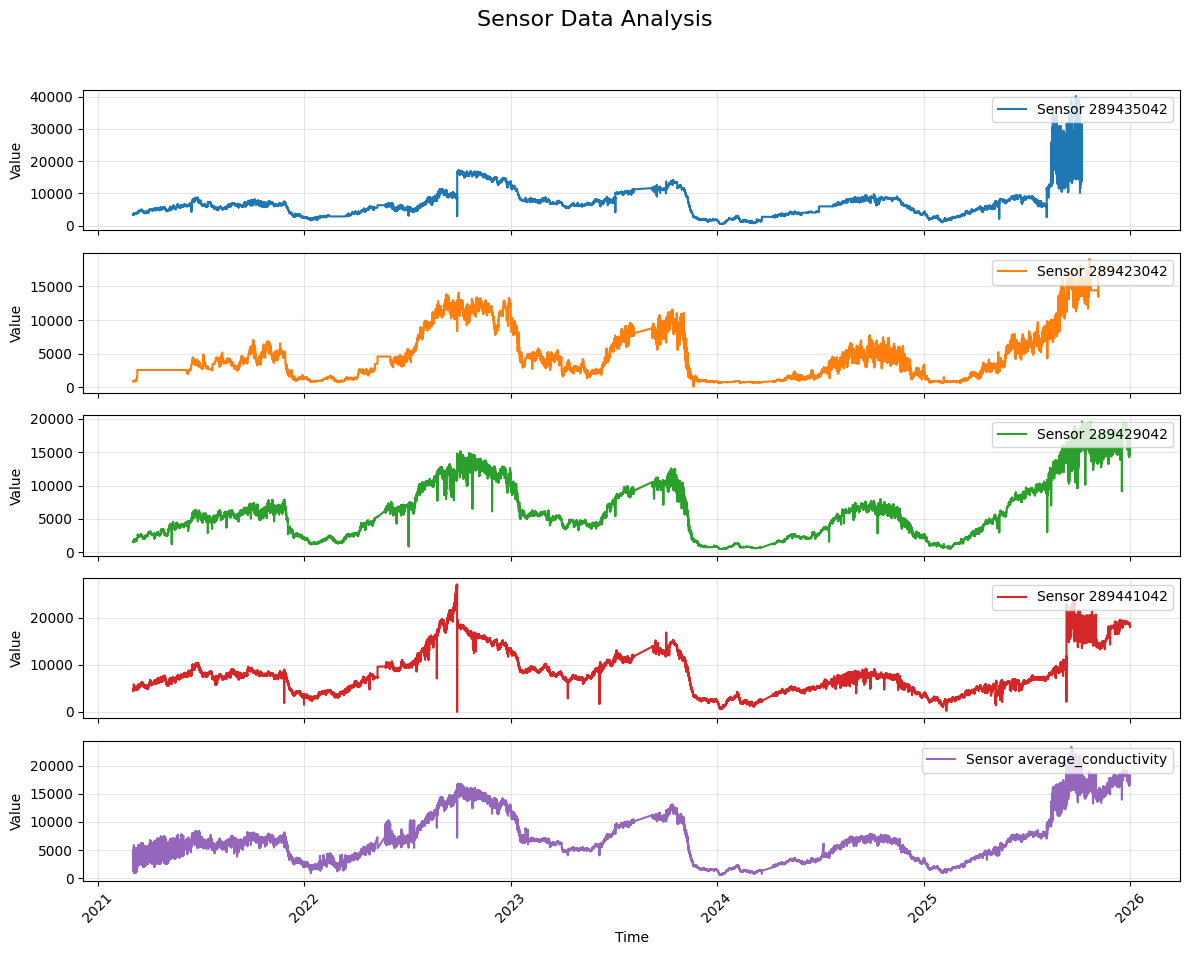

In [10]:
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(12, 10), sharex=True)

sensors = ['289435042', '289423042', '289429042', '289441042']
colors  = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728','#9467bd']
final_df['average_conductivity'] = final_df[sensors].mean(axis=1)
final_df = final_df.bfill()
sensors_with_avg = sensors + ['average_conductivity']

for i, sensor in enumerate(sensors_with_avg):
    ax = axes[i]
    ax.plot(final_df.index, final_df[sensor], label=f"Sensor {sensor}", color=colors[i])
    ax.set_ylabel("Value")
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

plt.suptitle("Sensor Data Analysis", fontsize=16)
plt.xlabel("Time")
plt.xticks(rotation=45)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# A Quick 1-Dimensional Exploration

In [12]:
m = 30
mps = {}  # Store the 1-dimensional matrix profiles
motifs_idx = {}  # Store the index locations for each pair of 1-dimensional motifs (i.e., the index location of two smallest matrix profile values within each dimension)
for dim_name in sensors:
    mps[dim_name] = stumpy.stump(final_df[dim_name].astype(float), m)
    motif_distance = np.round(mps[dim_name][:, 0].astype(float).min(), 1)
    print(f"The motif pair matrix profile value in {dim_name} is {motif_distance}")
    motifs_idx[dim_name] = np.argsort(mps[dim_name][:, 0])[:2]

C:\Users\AYMANS\AppData\Roaming\Python\Python313\site-packages\stumpy\core.py:2336: RuntimeWarning: divide by zero encountered in divide
  Σ_T_inverse = 1.0 / Σ_T


The motif pair matrix profile value in 289435042 is 0.0


C:\Users\AYMANS\AppData\Roaming\Python\Python313\site-packages\stumpy\core.py:2336: RuntimeWarning: divide by zero encountered in divide
  Σ_T_inverse = 1.0 / Σ_T


The motif pair matrix profile value in 289423042 is 0.0
The motif pair matrix profile value in 289429042 is 0.0
The motif pair matrix profile value in 289441042 is 0.0
